In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("traffic.csv")

In [3]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df = df.sort_values('DateTime')

In [4]:
data = df['Vehicles'].values

In [5]:
# Normalize data
scaler = MinMaxScaler()

data = scaler.fit_transform(data.reshape(-1,1))

# Create a Sequences

In [6]:
# Sequence Function
X = []
y = []

sequence_length = 10

for i in range(sequence_length, len(data)):

    X.append(data[i-sequence_length:i])

    y.append(data[i])

X = np.array(X)
y = np.array(y)

In [7]:
# Train & test
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Build LSTM Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential([

    Input(shape=(X_train.shape[1], 1)),

    LSTM(50, activation='relu'),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse'
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0087 - val_loss: 0.0197
Epoch 2/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0081 - val_loss: 0.0197
Epoch 3/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0079 - val_loss: 0.0188
Epoch 4/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0078 - val_loss: 0.0181
Epoch 5/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0076 - val_loss: 0.0176
Epoch 6/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0075 - val_loss: 0.0180
Epoch 7/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0074 - val_loss: 0.0174
Epoch 8/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - val_loss: 0.0174
Epoch 9/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0072 - val_loss: 0.0171
Epoch 10/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0072 - val_loss: 0.0172


In [11]:
predictions = model.predict(X_test)

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [12]:
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

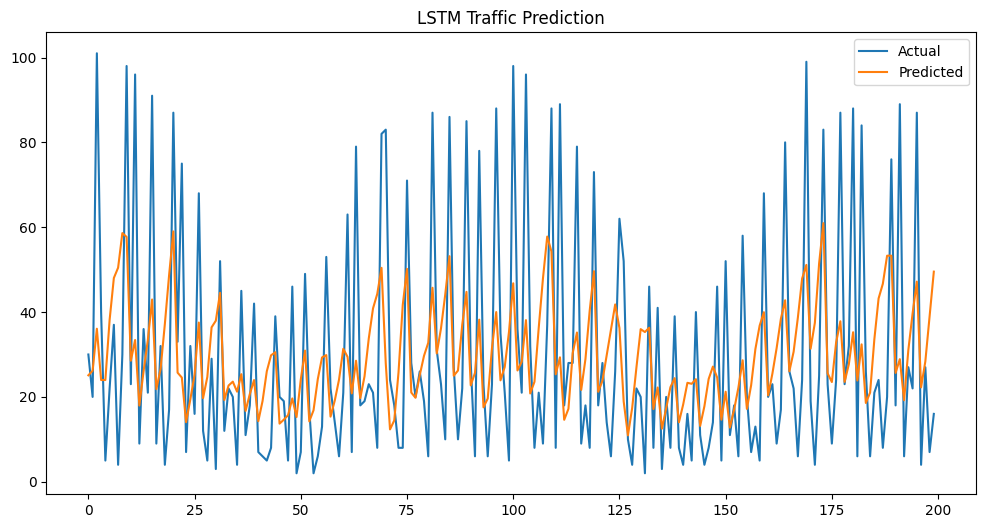

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual[:200], label='Actual')

plt.plot(predictions[:200], label='Predicted')

plt.legend()

plt.title("LSTM Traffic Prediction")

plt.show()

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


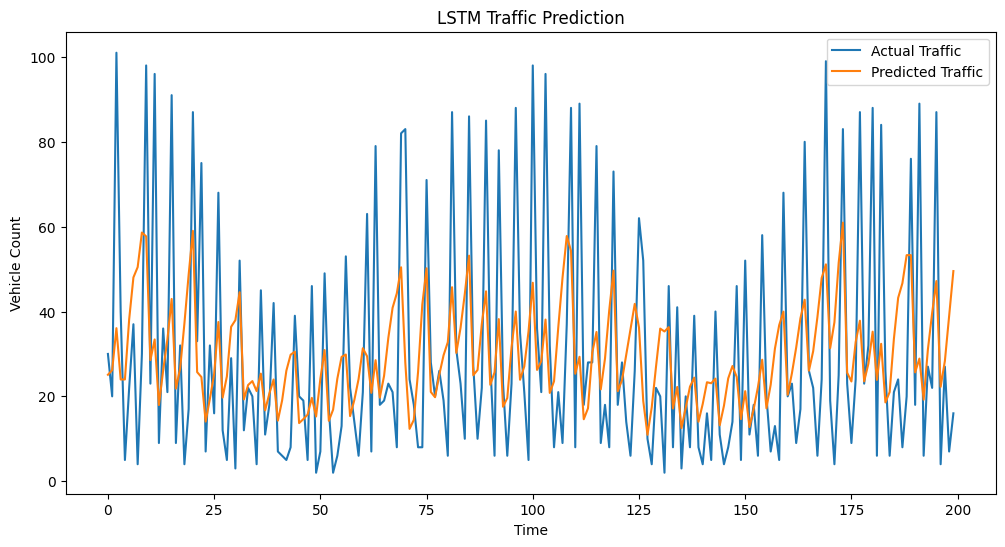

In [15]:
# Predict
predictions = model.predict(X_test)

# Reshape y_test properly
y_test = y_test.reshape(-1, 1)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(12,6))

plt.plot(y_test_actual[:200], label='Actual Traffic')

plt.plot(predictions[:200], label='Predicted Traffic')

plt.legend()

plt.title("LSTM Traffic Prediction")

plt.xlabel("Time")

plt.ylabel("Vehicle Count")

plt.show()

# Forecast Future Traffic

In [16]:
future_steps = 24

last_sequence = data[-sequence_length:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_steps):

    prediction = model.predict(
        current_sequence.reshape(1, sequence_length, 1),
        verbose=0
    )

    future_predictions.append(prediction[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        prediction
    )

# Convert back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

Plot Future Forecast

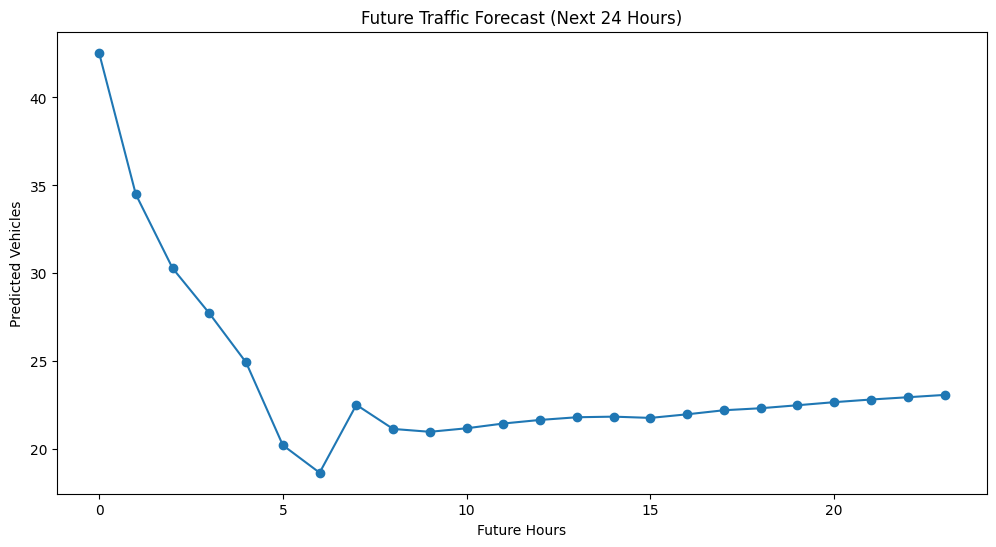

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title("Future Traffic Forecast (Next 24 Hours)")

plt.xlabel("Future Hours")

plt.ylabel("Predicted Vehicles")

plt.show()

In [19]:
# Convert DateTime column
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Create time-based features
df['hour'] = df['DateTime'].dt.hour

df['day'] = df['DateTime'].dt.day

df['month'] = df['DateTime'].dt.month

In [20]:
# Prepare Features
features = [
    'Vehicles',
    'hour',
    'day',
    'month',
    'Junction'
]

data = df[features]

In [21]:
print(df.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'hour', 'day', 'month'], dtype='str')


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [23]:
# Create Sequences
X = []
y = []

sequence_length = 10

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

In [24]:
# train test split
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
# Build Advanced LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64, return_sequences=True),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse'
)

Train

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0086 - val_loss: 0.0191
Epoch 2/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0077 - val_loss: 0.0181
Epoch 3/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0074 - val_loss: 0.0173
Epoch 4/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0073 - val_loss: 0.0191
Epoch 5/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0072 - val_loss: 0.0191
Epoch 6/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0070 - val_loss: 0.0191
Epoch 7/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0070 - val_loss: 0.0187
Epoch 8/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0069 - val_loss: 0.0201
Epoch 9/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0068 - val_loss: 0.0173
Epoch 10/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0067 - val_loss: 0.0178


Scale Multivariate Data

In [27]:
features = [
    'Vehicles',
    'hour',
    'day',
    'month',
    'Junction'
]

data = df[features]

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(48120, 5)


In [29]:
# Create Sequences
X = []
y = []

sequence_length = 10

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    # Vehicles column is index 0
    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(48110, 10, 5)
(48110,)


In [30]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [31]:
# Build Advanced Deep LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)

model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(1)

])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train Advanced Module
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0088 - val_loss: 0.0182
Epoch 2/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0077 - val_loss: 0.0178
Epoch 3/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0074 - val_loss: 0.0194
Epoch 4/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0072 - val_loss: 0.0181
Epoch 5/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0072 - val_loss: 0.0169
Epoch 6/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0070 - val_loss: 0.0186
Epoch 7/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0070 - val_loss: 0.0176
Epoch 8/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0069 - val_loss: 0.0215
Epoch 9/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0068 - val_loss: 0.0176
Epoch 10/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0068 - val_loss: 0.0180


In [33]:
# Predict
predictions = model.predict(X_test)

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [34]:
# Convert Back to Original Scale
vehicles_min = scaler.data_min_[0]
vehicles_max = scaler.data_max_[0]

In [35]:
predictions_actual = (
    predictions * (vehicles_max - vehicles_min)
) + vehicles_min

y_test_actual = (
    y_test.reshape(-1,1) * (vehicles_max - vehicles_min)
) + vehicles_min

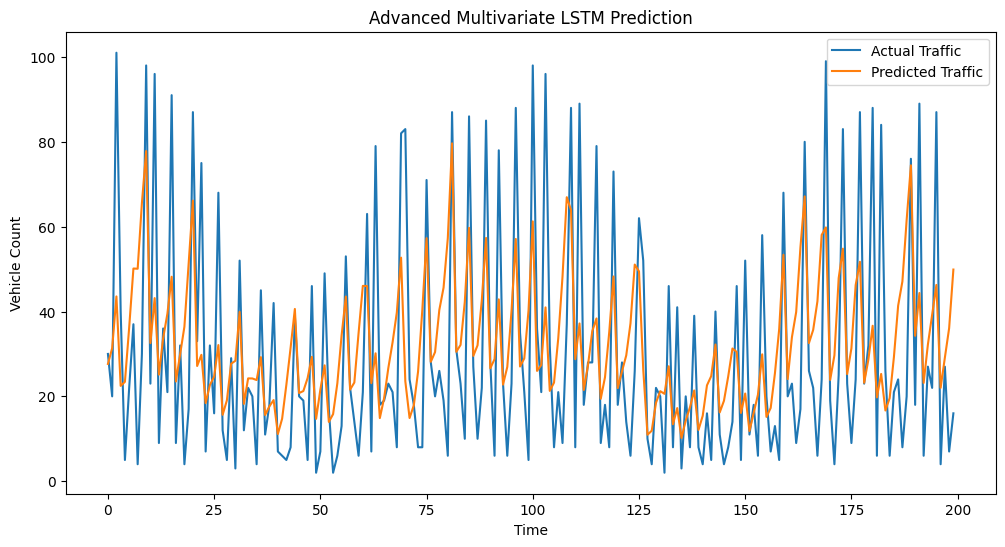

In [36]:
# plot Advanced Forecast
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:200],
    label='Actual Traffic'
)

plt.plot(
    predictions_actual[:200],
    label='Predicted Traffic'
)

plt.legend()

plt.title("Advanced Multivariate LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Vehicle Count")

plt.show()